In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
dataDirList = ['archive/GarbageClassification']
# dataDirList = ['/content/drive/MyDrive/archive/Garbage classification/Garbage classification']

selectedClasses = ['metal', 'glass', 'paper', 'trash', 'cardboard', 'plastic']

In [4]:
df = pd.read_csv("Original.csv")

In [5]:
imgPaths = []
labels = []
for dataDir in dataDirList:
    for className in os.listdir(dataDir):
        if className in selectedClasses :
            classPath = os.path.join(dataDir,className)
            for img in os.listdir(classPath):
                imgPath = os.path.join(classPath,img)
                imgPaths.append(imgPath)
                labels.append(className)

# Convert the 2 lists to dataframe to easy use
df = pd.DataFrame({
    'imgPath':imgPaths,
    'label':labels
})

df = df.sample(frac=1).reset_index(drop=True)            # Shuffle

df

,imgPath,label
0,archive/GarbageClassification\cardboard\cardbo...,cardboard
1,archive/GarbageClassification\plastic\plastic4...,plastic
2,archive/GarbageClassification\paper\paper447.jpg,paper
3,archive/GarbageClassification\glass\glass26.jpg,glass
4,archive/GarbageClassification\metal\metal171.jpg,metal
...,...,...
2522,archive/GarbageClassification\metal\metal319.jpg,metal
2523,archive/GarbageClassification\paper\paper71.jpg,paper
2524,archive/GarbageClassification\cardboard\cardbo...,cardboard
2525,archive/GarbageClassification\plastic\plastic1...,plastic


In [6]:
df['label'].value_counts()

label
paper        594
glass        501
plastic      482
metal        410
cardboard    403
trash        137
Name: count, dtype: int64

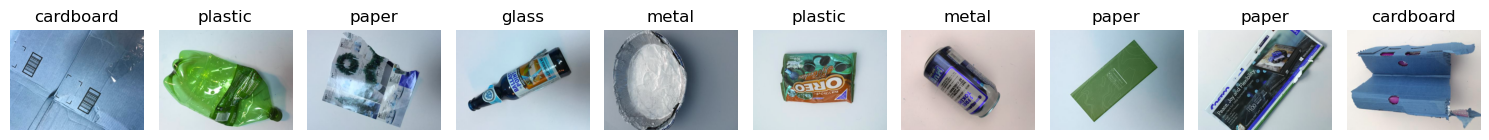

In [7]:
def plot_images_from_df(df, num_images=3):
    # Set up the matplotlib figure and axes
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))

    # Loop through the number of images you want to display
    for i in range(num_images):
        # Read the image from the path
        image_path = df.iloc[i]['imgPath']
        label = df.iloc[i]['label']

        # Load image using OpenCV and convert from BGR to RGB for matplotlib
        image = cv2.imread(image_path)
        # image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Plot the image on the corresponding subplot
        axes[i].imshow(image)
        axes[i].set_title(label)  # Set the title as the label
        axes[i].axis('off')       # Hide axis for a cleaner look

    plt.tight_layout()
    plt.show()

# Call the function to plot images
plot_images_from_df(df, num_images=10)  # Specify the number of images to plot

In [8]:
df_gaussian_blur = df.copy()

In [9]:
# Function to apply Gaussian blur and update DataFrame with new image paths
def apply_gaussian_blur_to_paths(df, save_path):
    for idx, row in df.iterrows():
        # Read the original image
        image_path = row['imgPath']
        # image = cv2.imread(image_path)

        # Apply Gaussian Blur
        # blurred_image = cv2.GaussianBlur(image, (5, 5), 0)

        # Save the blurred image to a new file
        filename = os.path.basename(image_path)
        blurred_image_path = os.path.join(save_path, f"blurred_{filename}")
        # cv2.imwrite(blurred_image_path, blurred_image)

        # Update the DataFrame with the new image path
        df.at[idx, 'imgPath'] = blurred_image_path
        
# Example: Update DataFrame with blurred images saved to a new folder
apply_gaussian_blur_to_paths(df_gaussian_blur, save_path='Gaussian_Blured')  # Replace with your save path
# apply_gaussian_blur_to_paths(df_gaussian_blur, save_path='/content/drive/MyDrive/Gaussian_Blured')  # Replace with your save path

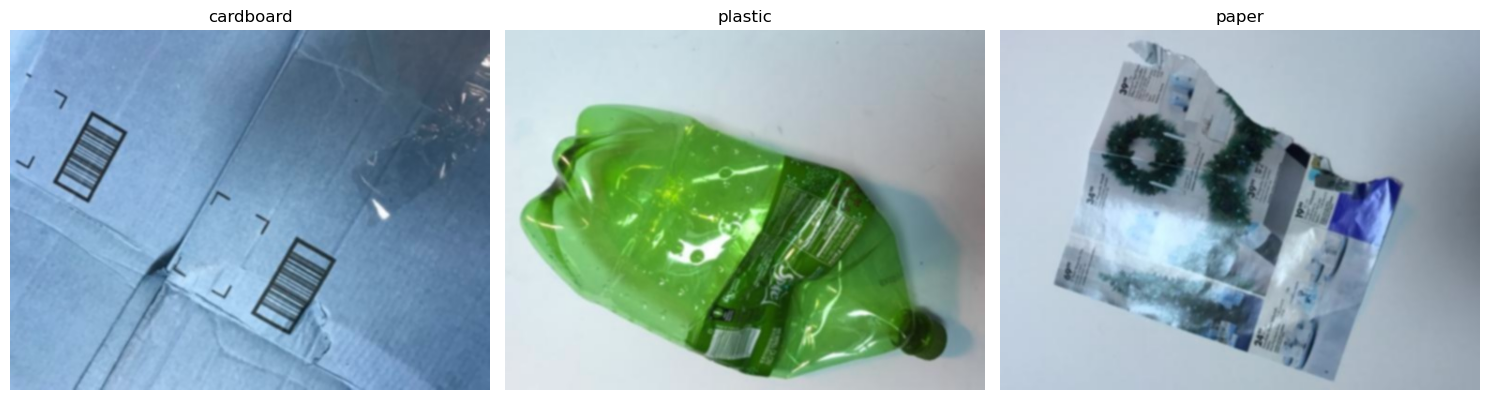

In [10]:
plot_images_from_df(df_gaussian_blur,3)

In [11]:
df_edges = df.copy()

In [12]:
# Function to apply Edge Detection and update DataFrame with new image paths
def apply_edge_detection_to_paths(df, save_path):
    for idx, row in df.iterrows():
        # Read the original image
        image_path = row['imgPath']
        # image = cv2.imread(image_path)

        # Apply Gaussian Blur
        # edges = cv2.Canny(image, 100, 200)

        # Save the blurred image to a new file
        filename = os.path.basename(image_path)
        edges_image_path = os.path.join(save_path, f"edges_{filename}")
        print(edges_image_path)
        # cv2.imwrite(edges_image_path, edges)

        # Update the DataFrame with the new image path
        df.at[idx, 'imgPath'] = edges_image_path

# Example: Update DataFrame with blurred images saved to a new folder
apply_edge_detection_to_paths(df_edges, save_path='edges')  # Replace with your save path
# apply_edge_detection_to_paths(df_edges, save_path='/content/drive/MyDrive/edges')  # Replace with your save path

edges\edges_cardboard12.jpg
edges\edges_plastic472.jpg
edges\edges_paper447.jpg
edges\edges_glass26.jpg
edges\edges_metal171.jpg
edges\edges_plastic477.jpg
edges\edges_metal339.jpg
edges\edges_paper168.jpg
edges\edges_paper405.jpg
edges\edges_cardboard200.jpg
edges\edges_glass271.jpg
edges\edges_cardboard315.jpg
edges\edges_metal274.jpg
edges\edges_plastic215.jpg
edges\edges_cardboard222.jpg
edges\edges_cardboard134.jpg
edges\edges_paper32.jpg
edges\edges_cardboard198.jpg
edges\edges_metal378.jpg
edges\edges_glass385.jpg
edges\edges_glass273.jpg
edges\edges_metal119.jpg
edges\edges_plastic138.jpg
edges\edges_glass307.jpg
edges\edges_glass298.jpg
edges\edges_paper55.jpg
edges\edges_glass411.jpg
edges\edges_glass229.jpg
edges\edges_glass183.jpg
edges\edges_metal404.jpg
edges\edges_plastic357.jpg
edges\edges_metal391.jpg
edges\edges_plastic130.jpg
edges\edges_glass186.jpg
edges\edges_trash127.jpg
edges\edges_paper51.jpg
edges\edges_plastic27.jpg
edges\edges_paper573.jpg
edges\edges_plasti

In [13]:
df_gaussian_blur

,imgPath,label
0,Gaussian_Blured\blurred_cardboard12.jpg,cardboard
1,Gaussian_Blured\blurred_plastic472.jpg,plastic
2,Gaussian_Blured\blurred_paper447.jpg,paper
3,Gaussian_Blured\blurred_glass26.jpg,glass
4,Gaussian_Blured\blurred_metal171.jpg,metal
...,...,...
2522,Gaussian_Blured\blurred_metal319.jpg,metal
2523,Gaussian_Blured\blurred_paper71.jpg,paper
2524,Gaussian_Blured\blurred_cardboard357.jpg,cardboard
2525,Gaussian_Blured\blurred_plastic195.jpg,plastic


In [14]:
df_edges

,imgPath,label
0,edges\edges_cardboard12.jpg,cardboard
1,edges\edges_plastic472.jpg,plastic
2,edges\edges_paper447.jpg,paper
3,edges\edges_glass26.jpg,glass
4,edges\edges_metal171.jpg,metal
...,...,...
2522,edges\edges_metal319.jpg,metal
2523,edges\edges_paper71.jpg,paper
2524,edges\edges_cardboard357.jpg,cardboard
2525,edges\edges_plastic195.jpg,plastic


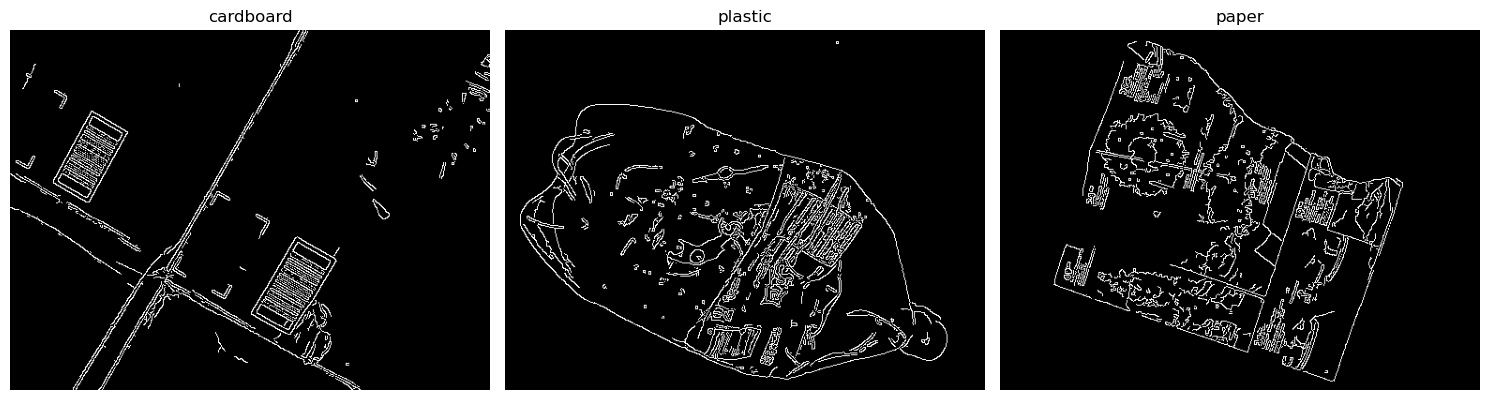

In [15]:
plot_images_from_df(df_edges,3)

In [16]:
# df.to_csv("Original.csv")
# df_gaussian_blur.to_csv("Gaussian.csv")
# df_edges.to_csv("Edges.csv")

In [17]:
def preprocess_images_and_labels(df, target_size=(224, 224), classes=None):
    # If no classes list is provided, extract unique labels from the DataFrame
    if classes is None:
        classes = df['label'].unique().tolist()

    preprocessed_images = []
    preprocessed_labels = []

    for _, row in df.iterrows():
        img_path = row['imgPath']
        label = row['label']

        # Step 1: Load the image using OpenCV
        img = cv2.imread(img_path)

        # Step 2: Resize the image to the target size
        img_resized = cv2.resize(img, target_size)

        # Step 3: Normalize the image pixel values to [0, 1]
        img_normalized = img_resized / 255.0

        # Append the preprocessed image to the list
        preprocessed_images.append(img_normalized)

        # Step 4: One-hot encode the label
        label_one_hot = np.zeros(len(classes))
        label_one_hot[classes.index(label)] = 1

        # Append the one-hot encoded label to the list
        preprocessed_labels.append(label_one_hot)

    # Convert lists to NumPy arrays
    preprocessed_images = np.array(preprocessed_images)
    preprocessed_labels = np.array(preprocessed_labels)

    return preprocessed_images, preprocessed_labels

# Example usage with your DataFrame (df containing imgPath and label columns):
target_size = (224, 224)
classes = df['label'].unique().tolist()  # Get unique classes from the 'label' column

# Preprocess images and labels
preprocessed_images, preprocessed_labels = preprocess_images_and_labels(df_edges, target_size=target_size, classes=classes)

# Check the results
print(preprocessed_images.shape)
print(preprocessed_labels.shape)

(2527, 224, 224, 3)
(2527, 6)


In [18]:
from sklearn.model_selection import train_test_split

# Split the data (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(preprocessed_images, preprocessed_labels, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}, Validation data shape: {X_val.shape}")

Training data shape: (2021, 224, 224, 3), Validation data shape: (506, 224, 224, 3)


In [19]:
import cv2
import pandas as pd

# Initialize the feature detector
sift = cv2.SIFT_create()
akaze = cv2.AKAZE_create()

# Define a function to apply on each image path
def compute_features_sift(image_path):
    image = cv2.imread(image_path)
    if image is not None:
        keypoints, descriptors = sift.detectAndCompute(image, None)
        descriptors = np.float32(descriptors)
        return keypoints, descriptors
    else:
        return None, None

# Apply the function to each image path in df_edges and store the result in two separate columns
df_edges["sift_keypoint"], df_edges["sift_descriptor"] = zip(*df_edges["imgPath"].apply(compute_features_sift))
df_gaussian_blur["sift_keypoint"], df_gaussian_blur["sift_descriptor"] = zip(*df_gaussian_blur["imgPath"].apply(compute_features_sift))

def compute_features_akaze(image_path):
    image = cv2.imread(image_path)
    if image is not None:
        keypoints, descriptors = akaze.detectAndCompute(image, None)
        descriptors = np.float32(descriptors)
        return keypoints, descriptors
    else:
        return None, None

df_edges["akaze_keypoint"], df_edges["akaze_descriptor"] = zip(*df_edges["imgPath"].apply(compute_features_akaze))
df_gaussian_blur["akaze_keypoint"], df_gaussian_blur["akaze_descriptor"] = zip(*df_gaussian_blur["imgPath"].apply(compute_features_akaze))



In [20]:
len(df_edges["sift_keypoint"][1])

619

In [21]:
# df_gaussian_blur.to_csv("Gaussian.csv")
# df_edges.to_csv("Edges.csv")

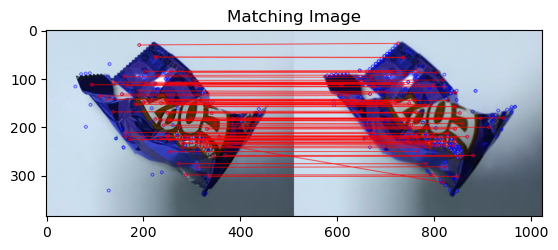

trash


In [22]:
# #create a system to find correspondences between several images( using keypoints matching) and apply it in recognition
# #use sift and akaze to find keypoints and descriptors
# #use flann to match the descriptors
# #use homography to find the transformation matrix
# #use warp perspective to apply the transformation matrix to the image
# #use the transformed image to train a model
# #use the model to predict the class of the image

# # Initialize the feature matcher
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=1, trees=10)
search_params = dict(checks=100)
flann = cv2.FlannBasedMatcher(index_params, search_params)

# # Define a function to apply on each row of the DataFrame


def match_features(gaussian_blur, best_matches=0):
    target = cv2.imread('target/trash66.jpg')
    gray_target = cv2.cvtColor(target, cv2.COLOR_BGR2GRAY)
    gray_target = cv2.GaussianBlur(gray_target, (11,11), 0)
    gray_target = cv2.equalizeHist(gray_target, None)
    sift = cv2.SIFT_create()
    target_keypoint, target_descriptor = sift.detectAndCompute(gray_target, None)
    target_descriptor = np.float32(target_descriptor)
    # print(target_descriptor)
    # print(target_descriptor.shape)
    best_matches_data = None
    for index,row in gaussian_blur.iterrows():
        

        # Get the descriptors from the row
        sift_descriptor = row['sift_descriptor']
        # print(sift_descriptor)
        # print(sift_descriptor.shape)
        # print(type(sift_descriptor))
        akaze_descriptor = row['akaze_descriptor']
        # print(sift_descriptor)
        # print(akaze_descriptor)
        
        # If either of the descriptors is None, return None
        if sift_descriptor is None:
            continue
        if isinstance(sift_descriptor, np.float32):
            continue
        if sift_descriptor.shape[0] < 2:
            continue

        # Match the descriptors using FLANN
        matches = flann.knnMatch(target_descriptor, sift_descriptor, k=2)
        matchesMask = [[0,0] for _ in range(0, len(matches))]
        current_matches = 0
        for i, (fm, sm) in enumerate(matches):
            if fm.distance < 0.7 * sm.distance:
                matchesMask[i] = [1,0]
                current_matches += 1
        
        if best_matches < current_matches:
            best_matches = current_matches
            img = cv2.imread(row['imgPath'])
            best_matches_data = {
                'image_data' : img,
                'keypoint': row['sift_keypoint'],
                'descriptor' : row['sift_descriptor'],
                'match' : matches,
                'matchesmask' : matchesMask,
                'label' : row['label']
            }
    result = cv2.drawMatchesKnn(
        target,
        target_keypoint,
        best_matches_data['image_data'],
        best_matches_data['keypoint'],
        best_matches_data['match'],
        None,
        matchesMask = best_matches_data['matchesmask'],
        matchColor = [255, 0, 0],
        singlePointColor = [0,0,255]
    )
    plt.figure()
    plt.imshow(result)
    plt.title("Matching Image")
    plt.show()
    print(best_matches_data['label'])

    

# Apply the function to each row in the DataFrame
# df_edges['num_good_matches'] = df_edges.apply(match_features, axis=1)
match_features(df_gaussian_blur)


# df_edges.head()

# df_gaussian_blur.head()

# df_edges.to_csv("Edges_matching.csv")
# df_gaussian_blur.to_csv("Gaussian_matching.csv")



In [ ]:
from sklearn.cluster import KMeans
from scipy.cluster.vq import vq

# Create a vocabulary of visual words using KMeans clustering
def build_vocabulary(descriptors_list, num_clusters=100):
    # print(descriptors_list)
    # print(len(descriptors_list))
    all_descriptors = descriptors_list[0]
    for desc in descriptors_list[1:]:
        if desc is None:
            continue
        if isinstance(desc, np.float32):
            continue
        if desc.shape[0] < 2:
            continue
        # print(len(desc))
        if np.isnan(desc).any() or np.isinf(desc).any():
            continue
        all_descriptors = np.vstack((all_descriptors, desc))
    kmeans = KMeans(n_clusters=num_clusters)
    kmeans.fit(all_descriptors)
    return kmeans

# Convert descriptors into histograms using the vocabulary (BoW model)
def compute_histograms(descriptors, kmeans):
    num_clusters = len(kmeans.cluster_centers_)
    
    if descriptors is None or descriptors.size == 0:
        return np.zeros(num_clusters)  # Return a zero histogram
    
    if np.isnan(descriptors).any() or np.isinf(descriptors).any():
        return np.zeros(num_clusters)  # Handle invalid descriptors

    # Assign each descriptor to a cluster (visual word)
    words, _ = vq(descriptors, kmeans.cluster_centers_)
    
    # Create a histogram of visual words
    histogram = np.zeros(num_clusters)
    
    # Ensure histogram size matches number of clusters
    for word in words:
        histogram[word] += 1
    
    return histogram

# Load images and extract features
def prepare_dataset(df, df_descriptors, detector='SIFT', num_clusters=100):
    descriptors_list = [desc for desc in df_descriptors if desc is not None and desc.size > 0]
    histograms = []
    # Build the BoW model
    kmeans = build_vocabulary(descriptors_list, num_clusters=num_clusters)
    
    # Compute histograms for each image
    for _, row in df.iterrows():
        descriptors = row['sift_descriptor']
        # print(type(descriptors))
        if descriptors is not None and descriptors.size > 0:
            histogram = compute_histograms(descriptors, kmeans)
            histograms.append(histogram)
    
    return np.array(histograms)

# Example images list

# PATH = 'archive/GarbageClassification/cardboard/'

X = prepare_dataset(df_gaussian_blur, df_gaussian_blur['sift_descriptor'], detector='SIFT', num_clusters=100)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split


2527
2527


In [31]:
# Assuming y contains the corresponding labels
# print(len(df_gaussian_blur['label']))
# print(len(X))
y = []
for label in df_gaussian_blur['label']:
    if label == "cardboard": y.append(0)
    if label == "glass": y.append(1)
    if label == "metal": y.append(2)
    if label == "paper": y.append(3)
    if label == "plastic": y.append(4)
    if label == "trash": y.append(5)

y = np.array(y)
# print(len(y))
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build a simple fully connected network
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')  # Adjust output size for your classes
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32)

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc}")

g:\Anaconda\envs\nlp\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.2575 - loss: 2.7485
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4447 - loss: 1.5293
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5124 - loss: 1.2590
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5898 - loss: 1.1391
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6435 - loss: 1.0065
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6539 - loss: 0.9705
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6687 - loss: 0.9149
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7192 - loss: 0.8061
Epoch 9/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7489 - loss: 0.7333
Epoch 10/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7644 - loss: 0.6662
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5586 - loss: 1.2843  
Test accuracy: 0.5454545617103577


In [ ]:
# Step 1: Import Required Libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Step 2: Define the Model Architecture
def build_model(input_shape, num_classes):
    model = Sequential()

    # First convolutional block
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D((2, 2)))

    # Second convolutional block
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))

    # Third convolutional block
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))

    # Flatten and fully connected layers
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))

    return model

# Step 3: Define Input Shape and Number of Classes
input_shape = (224, 224, 3)  # Assuming the images are resized to 224x224 with 3 color channels
classes = df['label'].unique().tolist()  # Define 'classes' as the unique labels from your DataFrame
num_classes = len(classes)               # Number of unique classes in your dataset

# Step 4: Build and Compile the Model
model = build_model(input_shape, num_classes)
model.summary()

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Step 5: Train the Model
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping]
)

# Step 6: Evaluate the Model
val_loss, val_accuracy = model.evaluate(X_val, y_val)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")

# Step 7: Save the Model
model.save('garbage_classification_model.h5')


c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 47s 715ms/step - accuracy: 0.2679 - loss: 1.8364 - val_accuracy: 0.3874 - val_loss: 1.5510
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 42s 653ms/step - accuracy: 0.4092 - loss: 1.4541 - val_accuracy: 0.4130 - val_loss: 1.5130
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 39s 617ms/step - accuracy: 0.5294 - loss: 1.2145 - val_accuracy: 0.4150 - val_loss: 1.5088
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 38s 592ms/step - accuracy: 0.6553 - loss: 0.9193 - val_accuracy: 0.4269 - val_loss: 1.7974
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 40s 619ms/step - accuracy: 0.7739 - loss: 0.6303 - val_accuracy: 0.4249 - val_loss: 1.8731
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 37s 583ms/step - accuracy: 0.8562 - loss: 0.4002 - val_accuracy: 0.4111 - val_loss: 2.6061
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 37s 573ms/step - accuracy: 0.8730 - loss: 0.3434 - val_accuracy: 0.4249 - val_loss: 2.1084
Epoch 8/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 38s 587ms/step - accuracy: 0.9187 - loss: 0.2425 - val_accu

Validation Loss: 1.5088225603103638
Validation Accuracy: 0.4150197505950928


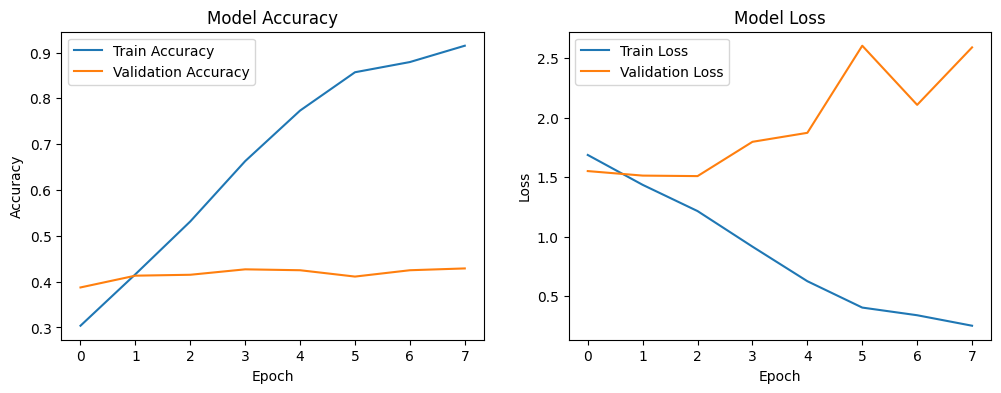

In [ ]:
plt.figure(figsize=(12, 4))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()
